### 🎯 [미션] 주석이 달린 줄의 None 또는 _______ 부분을 채워 코드를 완성하세요.

각 셀을 순서대로 실행(Shift + Enter)해야 합니다.

---

#### 1️⃣  필요한 라이브러리 설치 및 불러오기

In [1]:
# YOLO 라이브러리 설치 (최초 1회만 실행)
!pip install ultralytics

- YOLO 모델을 사용하기 위해서는 `ultralytics` 라이브러리의 핵심 모듈을 불러와야 합니다.

In [1]:
# 🎯 [미션] ultralytics 라이브러리에서 YOLO 모듈을 불러오세요.
from ultralytics import YOLO
from ultralytics import settings
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

---
#### 2️⃣ 경로 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
cd "/content/drive/MyDrive/2026_AI_Advanced_Study-main/4차시/01_AR/code"

In [2]:
# 현재 작업 디렉토리 확인
current_dir = os.getcwd()
new_runs_dir = os.path.abspath(os.path.join(current_dir, '../runs'))
new_data_dir = os.path.abspath(os.path.join(current_dir, '../data'))
# YOLO 설정 업데이트
settings.update({"runs_dir": new_runs_dir})
settings.update({"datasets_dir": new_data_dir})
settings.update({"wandb": False})  # wandb 로깅 비활성화

print(f"✅ 작업 디렉토리: {current_dir}")

print("\n✅ 경로 설정 완료!")

✅ 작업 디렉토리: /home/nute11a/workspace/2026_AI_Advanced_Study/4차시/01_AR/code_GT

✅ 경로 설정 완료!


---
### 3️⃣ 학습된 모델 불러오기 🔍
train.ipynb에서 학습한 모델의 경로를 찾아서 아래 MODEL_PATH 변수에 입력해주세요.

In [5]:
# 🎯 [미션] (01_train.ipynb에서 학습 후 생성된 weights/best.pt 파일 경로를 지정하세요)
model_path = '../runs/pose/train6/weights/best.pt'#'../runs/pose/train6/weights/best.pt' 
model = YOLO(model_path)

---

### 4️⃣ 얼굴 랜드마크 68개 점 확인하기 🙂

우리 모델이 얼굴에서 찾아낸 68개의 점을 시각화해봅시다.

각 점의 번호를 확인하면서, 어느 점이 **코**, **눈**, **입**에 해당하는지 파악해보세요!

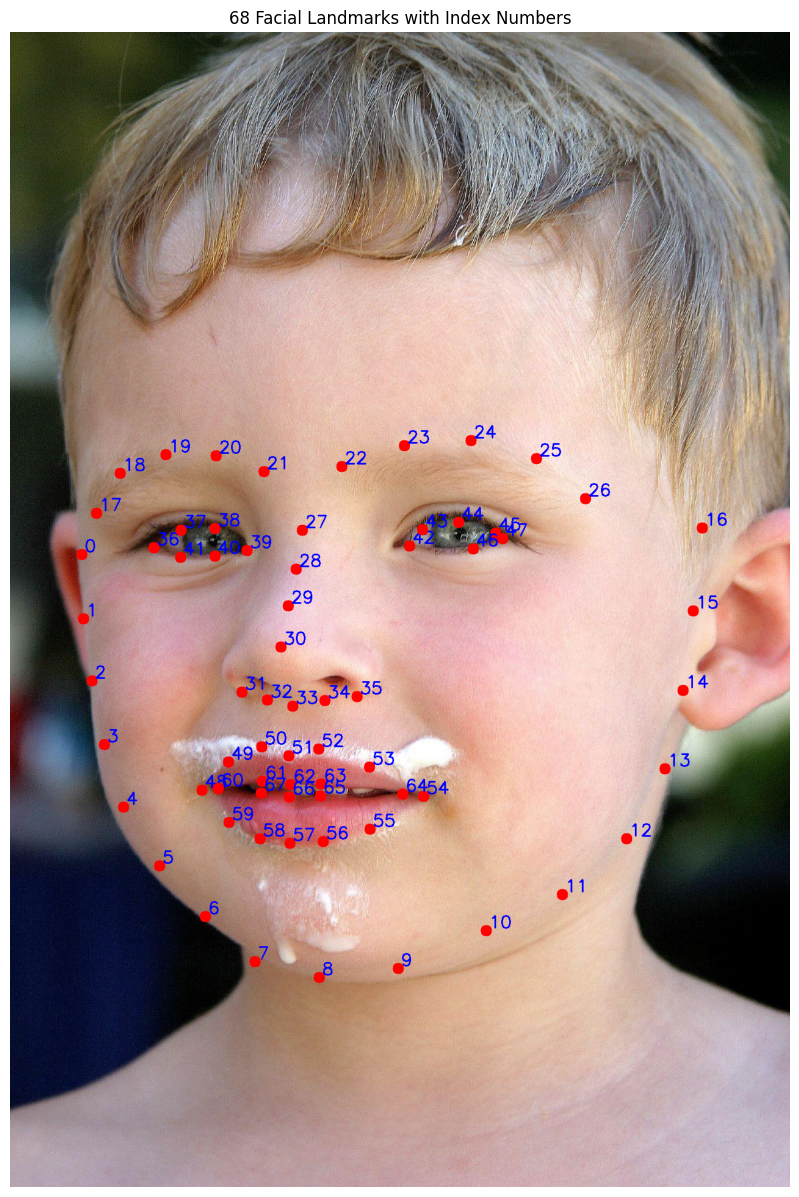


💡 위 이미지를 확대해서 각 점의 번호를 확인하세요!
코 끝은 몇 번일까요? 눈은요? 입은요?


In [23]:
# 테스트 이미지 경로 (여러분의 이미지로 변경 가능)
test_image_path = '../data/test/images/26638112_1.jpg'

# 모델 예측
results = model(test_image_path, verbose=False)

# 이미지와 키포인트 가져오기
img = results[0].orig_img.copy()
keypoints = results[0].keypoints.xy[0].cpu().numpy()

# 68개 점에 번호 표시
for i, (x, y) in enumerate(keypoints):
    cv2.circle(img, (int(x), int(y)), 10, (0, 0, 255), -1)
    cv2.putText(img, str(i), (int(x)+5, int(y)-5), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

# 결과 시각화
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('68 Facial Landmarks with Index Numbers')
plt.axis('off')
plt.show()

print("\n💡 위 이미지를 확대해서 각 점의 번호를 확인하세요!")
print("코 끝은 몇 번일까요? 눈은요? 입은요?")

---

### 🎨 AR 필터 만들기 시작!

이제부터 위에서 찾은 68개 점을 활용해서 **나만의 AR 필터**를 만들어봅시다!

**3단계 미션:**
- 🔴 **Level 1**: 루돌프 빨간 코 만들기
- 🕶️ **Level 2**: 힙한 선글라스 필터 만들기
- 🐱 **Level 3**: 고양이 필터 만들기 (도전!)


In [ ]:
def overlay_transparent(background, overlay, x, y):
    
    h, w = overlay.shape[:2]
    if y + h > background.shape[0] or x + w > background.shape[1]:
        return background
    if x < 0 or y < 0:
        return background
    
    overlay_bgr = overlay[:, :, :3]
    overlay_alpha = overlay[:, :, 3:] / 255.0
    background_region = background[y:y+h, x:x+w]
    blended = (overlay_bgr * overlay_alpha + 
               background_region * (1 - overlay_alpha)).astype('uint8')
    
    background[y:y+h, x:x+w] = blended
    return background

---
### 5️⃣ Level 1: 루돌프 빨간 코 만들기 🔴 

##### 목표
- 코 끝 랜드마크에 빨간 원 그리기
- 얼굴 크기에 비례해서 코 크기 자동 조절

##### 핵심
1. **기준점 설정**: 코 끝 좌표
2. **크기 조절**: 두 눈 사이 거리로 얼굴 크기 파악
3. **비율 계산**: `코 반지름 = 눈 간격 × 0.15`

In [ ]:
def draw_rudolf_nose(frame, model, rudolf_nose_img):

    # 🎯 [미션 1] 모델로 얼굴 랜드마크 추출
    results = model(frame, verbose=False)
    
    # 얼굴이 감지되지 않으면 원본 반환
    if results[0].keypoints is None or len(results[0].keypoints.xy) == 0:
        return frame
    
    # 키포인트 가져오기
    keypoints = results[0].keypoints.xy[0].cpu().numpy()
    
    # 🎯 [미션 2] 코 끝 좌표 가져오기 (힌트: 30번 또는 33번)
    nose_tip = keypoints[30]  # TODO: 빈칸 채우기 (30)
    
    # 얼굴 크기 기준: 두 눈 사이 거리
    # 왼쪽 눈 중심 (36~41번 평균)
    left_eye = keypoints[36:42].mean(axis=0)
    # 오른쪽 눈 중심 (42~47번 평균)
    right_eye = keypoints[42:48].mean(axis=0)
    
    # 🎯 [미션 3] 두 눈 사이 거리 계산 (힌트: np.linalg.norm 사용)
    eye_distance = np.linalg.norm(left_eye - right_eye)  # TODO: 빈칸 채우기
    
    # 🎯 [미션 4] 루돌프 코 크기 계산 (눈 간격의 30%)
    nose_width = int(eye_distance * 0.3)  # TODO: 빈칸 채우기 (0.3)
    
    # 원본 비율 유지하며 크기 조절
    aspect_ratio = rudolf_nose_img.shape[0] / rudolf_nose_img.shape[1]
    nose_height = int(nose_width * aspect_ratio)
    nose_resized = cv2.resize(rudolf_nose_img, (nose_width, nose_height))
    
    # 🎯 [미션 5] 루돌프 코 중심이 nose_tip에 오도록 위치 계산
    x = int(nose_tip[0] - nose_width // 2)   # TODO: 빈칸 채우기 (2)
    y = int(nose_tip[1] - nose_height // 2)  # TODO: 빈칸 채우기 (2)
    
    # 이미지 합성
    frame = overlay_transparent(frame, nose_resized, x, y)
    
    return frame

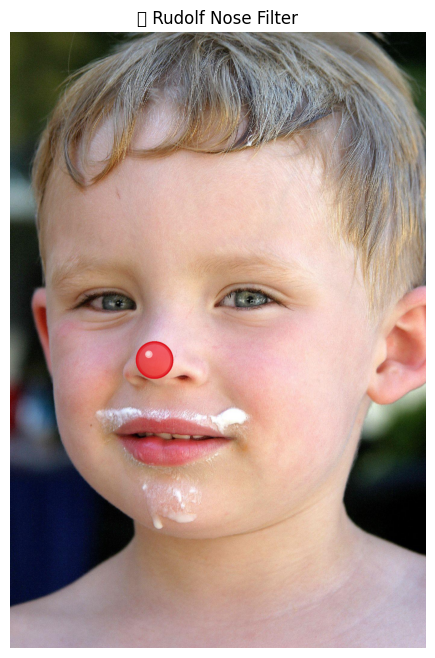

In [ ]:
# 루돌프 코 이미지 불러오기
rudolf_nose = cv2.imread('../data/assets/rudolf_nose.png', cv2.IMREAD_UNCHANGED)

if rudolf_nose is None:
    print("❌ 루돌프 코 이미지를 찾을 수 없습니다!")
else:
    # 테스트 이미지
    test_img = cv2.imread('../data/test/images/26638112_1.jpg')
    
    # 🎯 [미션 6] 함수 호출 (frame, model, 이미지 전달)
    result_img = draw_rudolf_nose(test_img, model, rudolf_nose)
    
    # 결과 시각화
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title('🔴 Rudolf Nose Filter')
    plt.axis('off')
    plt.show()

---
### 6️⃣ Level 2: 선글라스 필터 만들기 🕶️ 

##### 목표
- 투명 배경 PNG 이미지를 얼굴에 합성
- 얼굴 각도에 맞춰 이미지 회전
- 얼굴 크기에 맞춰 이미지 크기 조절

##### 핵심
1. **크기 조절**: 두 눈 사이 거리에 비례
2. **회전 각도**: `θ = arctan2(Δy, Δx)`
3. **Alpha Blending**: 투명 배경 처리

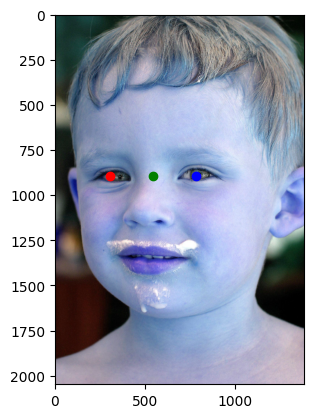

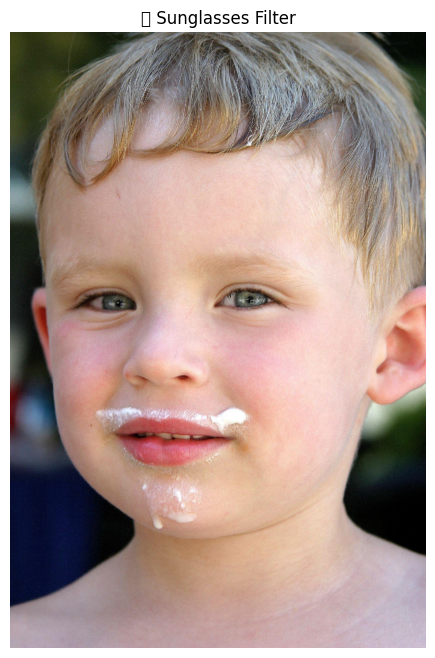

In [46]:
def draw_sunglasses(frame, model, glasses_img):

    # 🎯 [미션 1] 모델로 얼굴 랜드마크 추출
    results = model(frame, verbose=False)
    
    # 얼굴이 감지되지 않으면 원본 반환
    if results[0].keypoints is None or len(results[0].keypoints.xy) == 0:
        return frame
    
    # 키포인트 가져오기
    keypoints = results[0].keypoints.xy[0].cpu().numpy()
    
    # --- Step 1: 두 눈 중심 좌표 계산 ---
    # 🎯 [미션 2] 왼쪽 눈 중심 계산 (36~41번 평균)
    left_eye_center = keypoints[36:39].mean(axis=0)  # TODO: 빈칸 채우기 (36, 42)
    
    # 🎯 [미션 3] 오른쪽 눈 중심 계산 (42~47번 평균)
    right_eye_center = keypoints[42:47].mean(axis=0)  # TODO: 빈칸 채우기 (42, 48)
    
    # --- Step 2: 크기 계산 (두 눈 사이 거리 기반) ---
    # 🎯 [미션 4] 두 눈 사이 거리 계산
    eye_distance = np.linalg.norm(left_eye_center - right_eye_center)  # TODO: 빈칸 채우기
    
    # 선글라스는 눈보다 넓어야 함 (2.5배)
    glasses_width = int(eye_distance * 2.5)
    
    # 원본 비율 유지하며 크기 조절
    aspect_ratio = glasses_img.shape[0] / glasses_img.shape[1]
    glasses_height = int(glasses_width * aspect_ratio)
    glasses_resized = cv2.resize(glasses_img, (glasses_width, glasses_height))
    
    # --- Step 3: 회전 각도 계산 ---
    # 🎯 [미션 5] 두 눈을 잇는 선의 각도 계산
    # arctan2(Δy, Δx) → y는 [1], x는 [0]
    angle = np.degrees(np.arctan2(
        right_eye_center[1] - left_eye_center[1],  # TODO: Δy (1)
        right_eye_center[0] - left_eye_center[0]   # TODO: Δx (0)
    ))
    
    # 이미지 회전
    (h, w) = glasses_resized.shape[:2]
    rotation_matrix = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    glasses_rotated = cv2.warpAffine(glasses_resized, rotation_matrix, (w, h))
    
    # --- Step 4: 합성 위치 계산 (중심점 기준) ---
    # 🎯 [미션 6] 두 눈의 중점 계산
    center_point = ((left_eye_center + right_eye_center) / 2).astype(int)  # TODO: 빈칸 채우기
    
    # 🎯 [미션 7] 선글라스 중심이 center_point에 오도록 위치 계산
    x = center_point[0] - glasses_width // 2    # TODO: 2로 나누기
    y = center_point[1] - glasses_height // 2 - 10  # TODO: 2로 나누기 (살짝 위로)
    
    # --- Step 5: 이미지 합성 ---
    plt.imshow(frame)
    plt.scatter(left_eye_center[0], left_eye_center[1], c='red')
    plt.scatter(right_eye_center[0], right_eye_center[1], c='blue')
    plt.scatter(center_point[0], center_point[1], c='green')
    # plt.imshow(glasses_rotated)
    plt.show()
    frame = overlay_transparent(frame, glasses_rotated, center_point[0], center_point[1])
    
    return frame


# ===== 사용 예시 =====

# 선글라스 이미지 불러오기
# 🎯 [미션 8] 선글라스 이미지 로드 (4채널로!)
glasses = cv2.imread('../data/assets/sunglasses.png', cv2.IMREAD_UNCHANGED)

if glasses is None:
    print("❌ 선글라스 이미지를 찾을 수 없습니다!")
else:
    # 테스트 이미지
    test_image_path = '../data/test/images/26638112_1.jpg'
    test_img = cv2.imread(test_image_path)
    
    # 🎯 [미션 9] 함수 호출
    result_img = draw_sunglasses(test_img, model, glasses)  # TODO: model 넣기
    
    # 결과 시각화
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title('🕶️ Sunglasses Filter')
    plt.axis('off')
    plt.show()

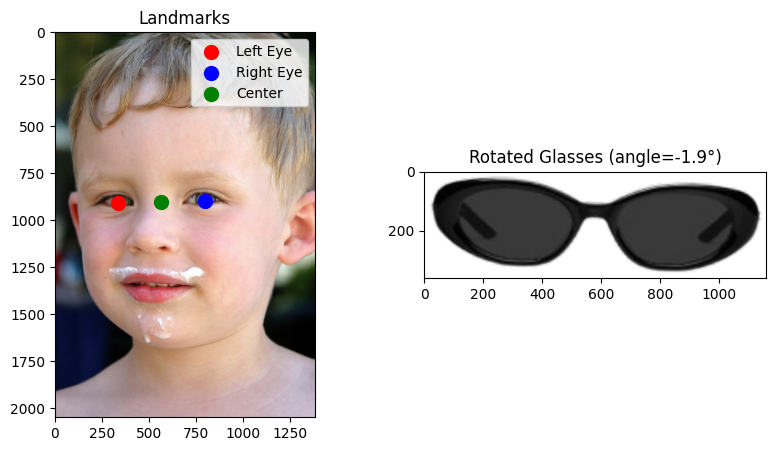

In [53]:
def draw_sunglasses(frame, model, glasses_img):
    """
    선글라스 필터 적용 (수정 버전)
    """
    
    # 모델로 얼굴 랜드마크 추출
    results = model(frame, verbose=False)
    
    # 얼굴이 감지되지 않으면 원본 반환
    if results[0].keypoints is None or len(results[0].keypoints.xy) == 0:
        return frame
    
    # 키포인트 가져오기
    keypoints = results[0].keypoints.xy[0].cpu().numpy()
    
    # --- Step 1: 두 눈 중심 좌표 계산 (수정!) ---
    # ✅ 왼쪽 눈: 36~41번 (6개)
    left_eye_center = keypoints[36:42].mean(axis=0)
    
    # ✅ 오른쪽 눈: 42~47번 (6개)
    right_eye_center = keypoints[42:48].mean(axis=0)
    
    # --- Step 2: 크기 계산 ---
    eye_distance = np.linalg.norm(right_eye_center - left_eye_center)
    glasses_width = int(eye_distance * 2.5)
    
    # 원본 비율 유지하며 크기 조절
    aspect_ratio = glasses_img.shape[0] / glasses_img.shape[1]
    glasses_height = int(glasses_width * aspect_ratio)
    glasses_resized = cv2.resize(glasses_img, (glasses_width, glasses_height))
    
    # --- Step 3: 회전 각도 계산 ---
    angle = np.degrees(np.arctan2(
        right_eye_center[1] - left_eye_center[1],
        right_eye_center[0] - left_eye_center[0]
    ))
    
    # ✅ 이미지 회전 (투명 배경 유지!)
    (h, w) = glasses_resized.shape[:2]
    rotation_matrix = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    
    # 중요: borderValue를 (0,0,0,0)으로 설정 (투명)
    glasses_rotated = cv2.warpAffine(
        glasses_resized, 
        rotation_matrix, 
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0, 0)  # ✅ 투명 배경
    )
    
    # --- Step 4: 합성 위치 계산 (수정!) ---
    center_point = ((left_eye_center + right_eye_center) / 2).astype(int)
    
    # ✅ 선글라스 중심이 center_point에 오도록 계산
    x = center_point[0] - glasses_width // 2
    y = center_point[1] - glasses_height // 2 - 10  # -10: 살짝 위로
    
    # 디버깅용 시각화 (선택사항)
    debug = True  # True로 바꾸면 중간 과정 확인 가능
    if debug:
        plt.figure(figsize=(15, 5))
        
        # 원본 + 랜드마크
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.scatter(left_eye_center[0], left_eye_center[1], c='red', s=100, label='Left Eye')
        plt.scatter(right_eye_center[0], right_eye_center[1], c='blue', s=100, label='Right Eye')
        plt.scatter(center_point[0], center_point[1], c='green', s=100, label='Center')
        plt.legend()
        plt.title('Landmarks')
        
        # 회전된 선글라스
        plt.subplot(1, 3, 2)
        plt.imshow(glasses_rotated)
        plt.title(f'Rotated Glasses (angle={angle:.1f}°)')
        
if glasses is None:
    print("❌ 선글라스 이미지를 찾을 수 없습니다!")
else:
    # 테스트 이미지
    test_image_path = '../data/test/images/26638112_1.jpg'
    test_img = cv2.imread(test_image_path)
    
    # 🎯 [미션 9] 함수 호출
    result_img = draw_sunglasses(test_img, model, glasses)  # TODO: model 넣기

✅ 선글라스 Shape: (62, 199, 4)


/home/nute11a/anaconda3/envs/SAT/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


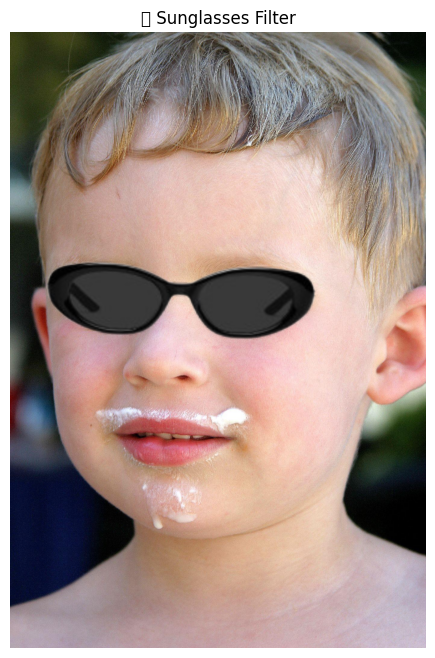

In [61]:
def overlay_transparent(background, overlay, x, y):
    """
    투명 PNG 이미지를 배경에 합성 (범위 초과 자동 처리)
    """
    h, w = overlay.shape[:2]
    bg_h, bg_w = background.shape[:2]
    
    # 합성 가능한 영역 계산
    src_x_start = max(0, -x)
    src_y_start = max(0, -y)
    dst_x_start = max(0, x)
    dst_y_start = max(0, y)
    
    src_x_end = min(w, bg_w - x)
    src_y_end = min(h, bg_h - y)
    dst_x_end = min(bg_w, x + w)
    dst_y_end = min(bg_h, y + h)
    
    # 합성 불가능하면 리턴
    if (src_x_end <= src_x_start or src_y_end <= src_y_start or
        dst_x_end <= dst_x_start or dst_y_end <= dst_y_start):
        return background
    
    # 영역 추출
    overlay_region = overlay[src_y_start:src_y_end, src_x_start:src_x_end]
    overlay_bgr = overlay_region[:, :, :3]
    overlay_alpha = overlay_region[:, :, 3:] / 255.0
    background_region = background[dst_y_start:dst_y_end, dst_x_start:dst_x_end]
    
    # Alpha blending
    blended = (overlay_bgr * overlay_alpha + 
               background_region * (1 - overlay_alpha)).astype('uint8')
    
    background[dst_y_start:dst_y_end, dst_x_start:dst_x_end] = blended
    
    return background


def draw_sunglasses(frame, model, glasses_img):
    """
    선글라스 필터 적용
    """
    results = model(frame, verbose=False)
    
    if results[0].keypoints is None or len(results[0].keypoints.xy) == 0:
        return frame
    
    keypoints = results[0].keypoints.xy[0].cpu().numpy()
    
    # 두 눈 중심
    left_eye_center = keypoints[36:42].mean(axis=0)
    right_eye_center = keypoints[42:48].mean(axis=0)
    
    # 크기 계산
    eye_distance = np.linalg.norm(right_eye_center - left_eye_center)
    
    # ✅ 크기를 줄임 (2.5 → 2.0)
    glasses_width = int(eye_distance * 2.0)  # 수정!
    
    aspect_ratio = glasses_img.shape[0] / glasses_img.shape[1]
    glasses_height = int(glasses_width * aspect_ratio)
    glasses_resized = cv2.resize(glasses_img, (glasses_width, glasses_height))
    
    # 회전
    angle = np.degrees(np.arctan2(
        right_eye_center[1] - left_eye_center[1],
        right_eye_center[0] - left_eye_center[0]
    ))
    
    (h, w) = glasses_resized.shape[:2]
    rotation_matrix = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    glasses_rotated = cv2.warpAffine(
        glasses_resized, 
        rotation_matrix, 
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0, 0)
    )
    
    # 위치 계산
    center_point = ((left_eye_center + right_eye_center) / 2).astype(int)
    x = center_point[0] - glasses_width // 2
    y = center_point[1] - glasses_height // 2 - 10
    
    # 합성 (개선된 overlay_transparent 사용)
    frame = overlay_transparent(frame, glasses_rotated, x, y)
    
    return frame


# 실행
glasses = cv2.imread('../data/assets/sunglasses.png', cv2.IMREAD_UNCHANGED)

if glasses is None:
    print("❌ 선글라스 이미지를 찾을 수 없습니다!")
else:
    print(f"✅ 선글라스 Shape: {glasses.shape}")
    
    test_img = cv2.imread('../data/test/images/26638112_1.jpg')
    
    if test_img is not None:
        result_img = draw_sunglasses(test_img, model, glasses)
        
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.title('🕶️ Sunglasses Filter')
        plt.axis('off')
        plt.show()